## Basic Imports

In [1]:
import pykep as pk
import heyoka as hy
import numpy as np
import pygmo as pg
import pygmo_plugins_nonfree as ppnf

from matplotlib import pyplot as plt

Setting up the NLP solver to be used

In [2]:
# IPOPT reference setup used consistently across all sections (use max_iter=100 for speed)
ipopt_integer_options = {
    "max_iter": 2000,
}
ipopt_numeric_options = {
    "tol": 1e-10,
}
ipopt_string_options = {
    "sb": "yes",
}

ipopt = pg.ipopt()
ipopt.set_integer_options(ipopt_integer_options)
ipopt.set_numeric_options(ipopt_numeric_options)
ipopt.set_string_options(ipopt_string_options)

# SNOPT reference setup used consistently across all sections
library_snopt72 = "/Users/dario.izzo/opt/libsnopt7_c.dylib"
snopt = ppnf.snopt7(library=library_snopt72, minor_version=2, screen_output=False)
snopt.set_integer_option("Major iterations limit", 2000)
snopt.set_integer_option("Iterations limit", 10000)
snopt.set_numeric_option("Major optimality tolerance", 1e-8)
snopt.set_numeric_option("Major feasibility tolerance", 1e-10)

algo = pg.algorithm(snopt)

## An Earth-Mars problem

We show the use of the {class}`pykep.trajopt.zoh_pl2pl` class to instantiate an Earth-Mars type of transfer. This is the main intended use of this
class and is relatively straight forward. The only obstacle being that of complying with the class requirements in terms of units which are mostly non dimensional, except those of the planet ephemerides.

In [3]:
# Problem data (SI units)
mu = pk.MU_SUN
max_thrust = 0.4  # (N)
isp = 3000  # (s)
veff = isp * pk.G0  # (m/s)
# Initial mass
ms = 1500.0  # (kg)
# tof bounds (in days)
tof_bounds = [100.0, 350.0]

# Number of segments
nseg = 10

# Source and destination planets (return m, m/s as a function of an epoch (days))
earth = pk.planet(pk.udpla.jpl_lp(body="EARTH"))
mars = pk.planet(pk.udpla.jpl_lp(body="MARS"))

# Lower tolerances result in higher speed (the needed tolerance depends on the orbital regime)
tol = 1e-10
tol_var = 1e-6
# We instantiate ZOH Taylor integrators for Keplerian dynamics.
ta = pk.ta.get_zoh_kep(tol)
ta_var = pk.ta.get_zoh_kep_var(tol_var)

# Units that will be used in the ZOH Taylor integrator.
L = pk.AU  # eph will return SI units, we divide by this number.
MU = mu  # (central body mu must be 1 as a requirement of pk.ta.get_zoh_kep)
TIME = np.sqrt(L**3 / MU)
V = np.sqrt(MU / L)
ACC = V**2 / L
MASS = ms
F = MASS * ACC

# Non dimensional quantities.
ms_nd = ms / MASS
veff_nd = veff / V
tof_bounds_nd = [it * pk.DAY2SEC / TIME for it in tof_bounds]
max_thrust_nd = max_thrust / F

# Creating Taylor-Adaptive Integrators
# The zoh_pl2pl class requires Taylor-adaptive integrators for trajectory propagation.
# 1. Nominal dynamics integrator (for fitness evaluation)
# 2. Variational dynamics integrator (for gradient computation)
ta.pars[4] = 1.0 / veff_nd
ta_var.pars[4] = 1.0 / veff_nd
print(f"Nominal integrator state dimension: {len(ta.state)}")
print(f"Variational integrator state dimension: {len(ta_var.state)}")

Nominal integrator state dimension: 7
Variational integrator state dimension: 84


In [4]:
udp = pk.trajopt.zoh_pl2pl(
    pls=earth,
    plf=mars,
    ms=ms_nd,
    nseg=nseg,
    cut=0.5,
    t0_bounds=[7360, 8300.0],  # (MJD2000)
    tof_bounds=tof_bounds_nd,
    mf_bounds=[2 / 3, 1.0],
    vinf_dep_bounds=[0.0, 0.033574293988433881],  # (1.0 km/s in non dimensional units)
    vinf_arr_bounds=[0.0, 0.0],
    tas=(ta, ta_var),
    max_thrust=max_thrust_nd,
    time_encoding="uniform",
    inequalities_for_tc=True,
    L=L,
    V=V,
)

print("UDP instance created successfully")
print(f"Gradient: {udp.has_gradient()}")
print(f"Inequality constraints:", udp.inequalities_for_tc)

UDP instance created successfully
Gradient: True
Inequality constraints: True


In [5]:
prob = pg.problem(udp)
prob.c_tol = 1e-6
# seed
seed = 42
pseudorandom = lambda i: (1103515245 * (i + seed) + 12345) % 2**31

masses = []
xs = []
for i in range(10):
    pop = pg.population(prob, 1, seed=pseudorandom(i))
    pop = algo.evolve(pop)
    if prob.feasibility_f(pop.champion_f):
        print(".", end="")
        masses.append(pop.champion_x[1])
        xs.append(pop.champion_x)
    else:
        print("x", end="")
print("\nBest mass is: ", np.max(masses) * MASS)
print("Worst mass is: ", np.min(masses) * MASS)
best_idx = np.argmax(masses)

x.x...xx.x
Best mass is:  1275.38210477
Worst mass is:  1255.85314286


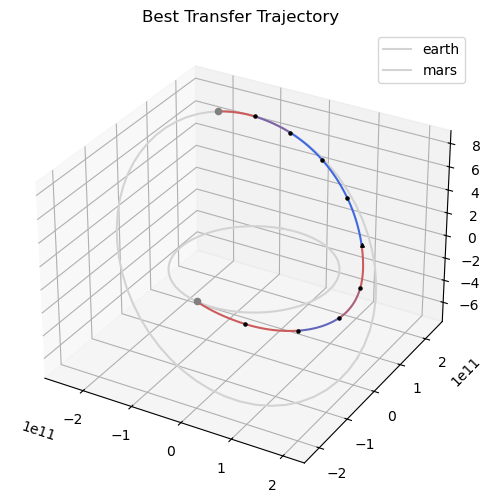

In [6]:
if len(xs) > 0:
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")
    t0 = udp.compute_t0(xs[best_idx])
    ax = pk.plot.add_planet_orbit(
        ax=ax, pla=earth, label="earth", units=1.0, color="lightgray"
    )
    ax = pk.plot.add_planet_orbit(
        ax=ax, pla=mars, label="mars", units=1.0, color="lightgray"
    )
    ax = udp.plot(xs[best_idx], ax=ax, N=20, c="k", s=5)
    ax = pk.plot.add_planet(ax=ax, when=t0, pla=earth, units=1.0, color="gray", s=20)
    ax = pk.plot.add_planet(
        ax=ax,
        when=t0 + xs[best_idx][10 + 4 * udp.nseg] * udp.TIME / pk.DAY2SEC,
        pla=mars,
        units=1.0,
        color="gray",
        s=20,
    )
    ax.set_title("Best Transfer Trajectory")
    ax.legend()

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

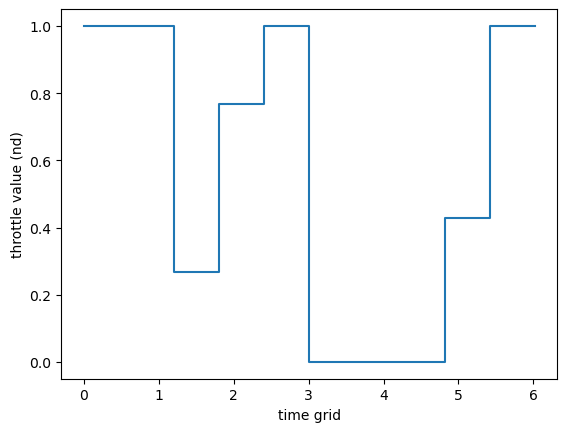

In [7]:
udp.plot_throttle(xs[best_idx])

# A problem from TOPS (twobody)

In [66]:
# We load the dictionary defining the problem
prob_dict = pk.trajopt.gym.tops_twobody_json["P0"].copy()

In [77]:
# These are the units declared in the original TOPS problem definition
L = prob_dict["L"]
TIME = prob_dict["TIME"]
MASS = prob_dict["MASS"]
V = L / TIME
MU = L**3 / TIME**2
ACC = V**2 / L
F = MASS * ACC

# We may thus instantiate the moving ends as keplerian planets
# assuming the TOPs state vectors are at epoch 0 and and at epoch tof_days respectively.
rs = [it * L for it in prob_dict["state_s"][0:3]]
vs = [it * V for it in prob_dict["state_s"][3:6]]
pls = pk.planet(
    pk.udpla.keplerian(when=pk.epoch(0.0), posvel=[rs, vs], mu_central_body=MU)
)
tof_days = prob_dict["tof_bounds"][0] * TIME * pk.SEC2DAY
rf = [it * L for it in prob_dict["state_f"][0:3]]
vf = [it * V for it in prob_dict["state_f"][3:6]]
plf = pk.planet(
    pk.udpla.keplerian(when=pk.epoch(tof_days), posvel=[rf, vf], mu_central_body=MU)
)
# To define a consistent version of the point w point problems as moving ends, we set the bounds
# on the departure epochs to allow for a movement of half an orbit
period_s_day = prob_dict["period_s"] * TIME * pk.SEC2DAY
bound = period_s_day / 4.0  # [-bound, bound] will be half

print(f"Thrust: {prob_dict["max_thrust"] * F} N")
print(f"Isp: {prob_dict["veff"] * V / pk.G0} s")
print(f"TOF: {tof_days} days")

Thrust: 0.33000000000000007 N
Isp: 3000.0 s
TOF: 639.4568495391286 days


In [ ]:
# We rescale the integrator units so that the initial state has unitary norm (for consistency across problems).
# This is not strictly necessary and introduces a third unit system (TOPS, integrator, and this) and likely confusion.
# But its hidden in the definition of the UDP, and the user should not "see" it, unless they want to
# actually recover the results in some of the other unit system (e.g. SI or TOPS) used in the problem definition.
L_ta = np.linalg.norm(prob_dict["state_s"][0:3])
MASS_ta = prob_dict["m_s"]
TIME_ta = np.sqrt(L_ta**3)
V_ta = L_ta / TIME_ta
ACC_ta = V_ta**2 / L_ta
F_ta = MASS_ta * ACC_ta

# Lower tolerances result in higher speed (the needed tolerance depends on the orbital regime)
tol = 1e-10
tol_var = 1e-6
# We instantiate ZOH Taylor integrators for Keplerian dynamics.
ta = pk.ta.get_zoh_kep(tol)
ta_var = pk.ta.get_zoh_kep_var(tol_var)

veff_nd = prob_dict["veff"] / V_ta
ta.pars[4] = 1.0 / veff_nd
ta_var.pars[4] = 1.0 / veff_nd

In [83]:
udp = pk.trajopt.zoh_pl2pl(
    pls=pls,
    plf=plf,
    ms=1.0,
    nseg=10,
    cut=0.5,
    t0_bounds=[-bound, bound],  # (MJD2000)
    tof_bounds=[it / TIME_ta for it in prob_dict["tof_bounds"]],
    mf_bounds=[2/3, 1.0],
    vinf_dep_bounds=[0.0, 0.0],
    vinf_arr_bounds=[0.0, 0.0],
    tas=(ta, ta_var),
    max_thrust=prob_dict["max_thrust"],
    time_encoding="softmax",
    inequalities_for_tc=True,
    L=L*L_ta,
    V=V*V_ta,
)

print("UDP instance created successfully")
print(f"Gradient: {udp.has_gradient()}")
print(f"Inequality constraints:", udp.inequalities_for_tc)

UDP instance created successfully
Gradient: True
Inequality constraints: True


In [84]:
prob = pg.problem(udp)
prob.c_tol = 1e-6
# seed
seed = 42
pseudorandom = lambda i: (1103515245 * (i + seed) + 12345) % 2**31

masses = []
xs = []
for i in range(10):
    pop = pg.population(prob, 1, seed=pseudorandom(i))
    pop = algo.evolve(pop)
    if prob.feasibility_f(pop.champion_f):
        print(".", end="")
        masses.append(pop.champion_x[1])
        xs.append(pop.champion_x)
    else:
        print("x", end="")
print("\nBest mass is: ", np.max(masses)*MASS_ta)
print("Worst mass is: ", np.min(masses)*MASS_ta)
best_idx = np.argmax(masses)

..xx..x...
Best mass is:  0.928522509514
Worst mass is:  0.925677181682


Text(0.5, 0.92, 'yz - view')

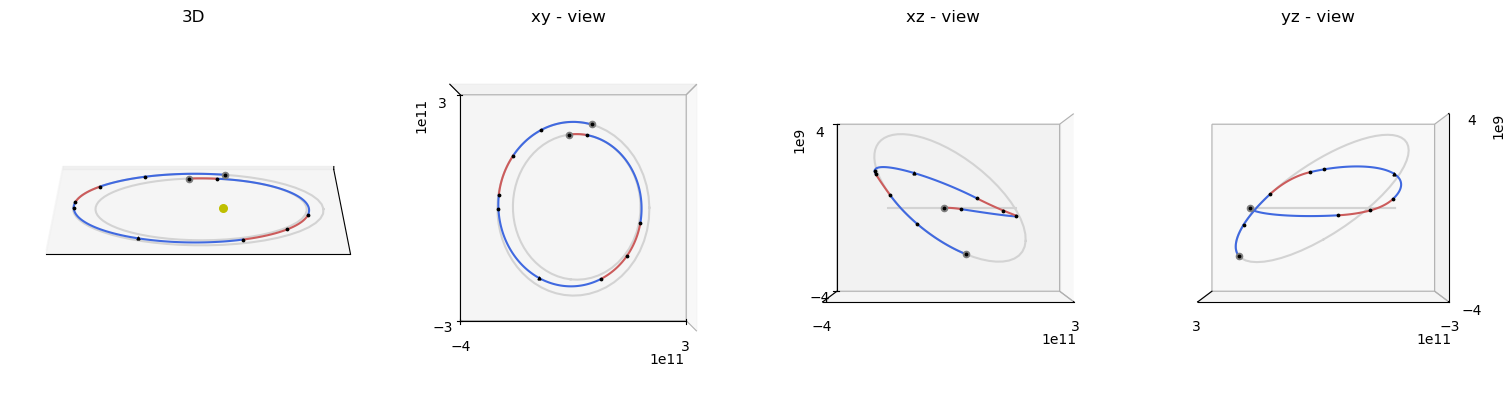

In [85]:
# Multi-view plotting helper for quick geometric inspection
fig = plt.figure(figsize=(15, 4), layout="constrained")

ax3d = fig.add_subplot(1, 4, 1, projection="3d")
ax_xy = fig.add_subplot(1, 4, 2, projection="3d")
ax_xz = fig.add_subplot(1, 4, 3, projection="3d")
ax_yz = fig.add_subplot(1, 4, 4, projection="3d")

axes = [ax3d, ax_xy, ax_xz, ax_yz]

t0 = udp.compute_t0(xs[best_idx])

for ax in axes:
    ax = pk.plot.add_planet_orbit(
        ax=ax, pla=pls, label="pls", units=1.0, color="lightgray"
    )
    ax = pk.plot.add_planet_orbit(
        ax=ax, pla=plf, label="plf", units=1.0, color="lightgray"
    )
    ax = pk.plot.add_planet(ax=ax, when=t0, pla=pls, units=1.0, color="gray", s=20)
    ax = pk.plot.add_planet(
        ax=ax,
        when=t0 + xs[best_idx][10 + 4 * udp.nseg] * udp.TIME / pk.DAY2SEC,
        pla=plf,
        units=1.0,
        color="gray",
        s=20,
    )
    udp.plot(x=xs[best_idx], N=100, mark_segments=True, s=3, c="k", ax=ax)


# Keep only boundary ticks to emphasize shape over scale details
for ax in axes:
    ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
    ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
    ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])
ax_xy.set_zticks([])
ax_xz.set_yticks([])
ax_yz.set_xticks([])

ax3d.view_init(elev=20, azim=270)
ax3d.set_aspect("equal")
pk.plot.add_sun(ax3d)

ax_xy.view_init(elev=90, azim=-90)
ax_xz.view_init(elev=0, azim=-90)
ax_yz.view_init(elev=0, azim=180)

ax3d.set_title("3D")
ax_xy.set_title("xy - view")
ax_xz.set_title("xz - view")
ax_yz.set_title("yz - view")

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

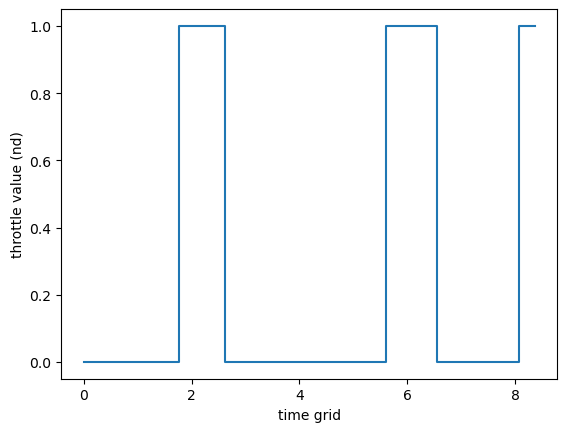

In [86]:
udp.plot_throttle(xs[best_idx])

# A problem from TOPS (mee)

In [87]:
# We load the dictionary defining the problem
prob_dict = pk.trajopt.gym.tops_mee_json["P0"].copy()
# Since these are mee problems we compute the number of revolutions as the difference in mean longitude divided by 2pi
nrevs = (prob_dict["state_f"][-1] - prob_dict["state_s"][-1]) // (np.pi * 2)

In [88]:
# We define the units declared in the TOPS problem definition
L = prob_dict["L"]
TIME = prob_dict["TIME"]
MASS = prob_dict["MASS"]
V = L / TIME
MU = L**3 / TIME**2
ACC = V**2 / L
F = MASS * ACC

# And instantiate the moving ends as planets
# We scale the non dimensional MEE state by the units to get physical units, 
# then we create the planet objects for the initial and final states.
mees = prob_dict["state_s"].copy()
mees[0]*=prob_dict["L"]
pls = pk.planet(
    pk.udpla.keplerian(when=pk.epoch(0.0), elem=mees, mu_central_body=prob_dict["mu"] * MU, el_type=pk.el_type.MEE)
)
# Same for the final state
meef = prob_dict["state_f"].copy()
meef[0]*=prob_dict["L"]
plf = pk.planet(
    pk.udpla.keplerian(when=pk.epoch(tof_days), elem=meef, mu_central_body=prob_dict["mu"] * MU, el_type=pk.el_type.MEE)
)

# To let boundary move we set the bounds on the departure epoch to allow for movement of hal an orbit
period_s_day = prob_dict["period_s"] * TIME * pk.SEC2DAY
bound = period_s_day / 4.0  # [-bound, bound] will be half

print(f"Thrust: {prob_dict["max_thrust"] * F} N")
print(f"Isp: {prob_dict["veff"] * V / pk.G0} s")
print(f"TOF: {tof_days} days")

Thrust: 0.12000341608328746 N
Isp: 2999.975462868034 s
TOF: 639.4568495391286 days


In [89]:
# We rescale the integrator units so that the initial state has unitary norm (for consistency across problems).
# This is not strictly necessary and introduces a third unit system (TOPS, integrator, and this) and likely confusion.
# But its hidden in the definition of the UDP, and the user should not "see" it, unless they want to
# actually recover the results in some of the other unit system (e.g. SI or TOPS) used in the problem definition.
L_ta = np.linalg.norm(prob_dict["state_s"][0:3])
MASS_ta = prob_dict["m_s"]
TIME_ta = np.sqrt(L_ta**3)
V_ta = L_ta / TIME_ta
ACC_ta = V_ta**2 / L_ta
F_ta = MASS_ta * ACC_ta

# Lower tolerances result in higher speed (the needed tolerance depends on the orbital regime)
tol = 1e-10
tol_var = 1e-6
# We instantiate ZOH Taylor integrators for mee dynamics.
ta = pk.ta.get_zoh_eq(tol)
ta_var = pk.ta.get_zoh_eq_var(tol_var)

# We set the effective exhaust velocity in the Taylor integrators
veff_nd = prob_dict["veff"] / V_ta
ta.pars[4] = 1.0 / veff_nd
ta_var.pars[4] = 1.0 / veff_nd


Since the state in the Taylor integrator is not Cartesian (mee in this case) we need to provide the transformation from Cartesian to mee as well as its Jacobian. We do so jitting the symbolic expressions provided in `pykep`

In [ ]:
# We get the symbolic expressions
cart2state, cart2state_J = pk.ic2mee(jacobian=True) # The API also requires the Jacobian
state2cart, _ = pk.mee2ic(jacobian=False) # The API does not require the Jacobian
# We jit them into cfuncs
x,y,z,vx,vy,vz = hy.make_vars("x", "y", "z", "vx", "vy", "vz")
p, f, g, h, k, L_anom = hy.make_vars("p", "f", "g", "h", "k", "L")
cart2state_cfunc = hy.cfunc(cart2state, vars=[x,y,z,vx,vy,vz])
cart2state_J_cfunc = hy.cfunc(cart2state_J, vars=[x,y,z,vx,vy,vz])
state2cart_cfunc = hy.cfunc(state2cart, vars=[p, f, g, h, k, L_anom])
# We create the call signature required by the API of the zoh_pl2pl class and
# account here for the nrevs in the mean longitude.
cart2state_zoh = lambda x: cart2state_cfunc(x, pars = [prob_dict["mu"], 1]) 
cart2state_J_zoh = lambda x: cart2state_J_cfunc(x, pars = [prob_dict["mu"], 1])
state2cart_zoh = lambda x: state2cart_cfunc(x, pars = [prob_dict["mu"], 1])

In [91]:
udp = pk.trajopt.zoh_pl2pl(
    pls=pls,
    plf=plf,
    ms=1.0,
    nseg=30,
    cut=0.5,
    t0_bounds=[-0.0, 0.0],  # (MJD2000)
    tof_bounds=prob_dict["tof_bounds"],
    mf_bounds=[0.5, 1.0],
    vinf_dep_bounds=[0.0, 0.0],
    vinf_arr_bounds=[0.0, 0.0],
    tas=(ta, ta_var),
    max_thrust=prob_dict["max_thrust"],
    time_encoding="softmax",
    inequalities_for_tc=True,
    cart2state = (cart2state_zoh, cart2state_J_zoh),
    L=L*L_ta,
    V=V*V_ta,
    nrevs=nrevs
)

print("UDP instance created successfully")
print(f"Gradient: {udp.has_gradient()}")
print(f"Inequality constraints:", udp.inequalities_for_tc)

UDP instance created successfully
Gradient: True
Inequality constraints: True


In [92]:
prob = pg.problem(udp)
prob.c_tol = 1e-7
# seed
seed = 42
pseudorandom = lambda i: (1103515245 * (i + seed) + 12345) % 2**31

masses = []
xs = []
for i in range(10):
    pop = pg.population(prob, 1, seed=pseudorandom(i))
    pop = algo.evolve(pop)
    if prob.feasibility_f(pop.champion_f):
        print(".", end="")
        masses.append(pop.champion_x[1])
        xs.append(pop.champion_x)
    else:
        print("x", end="")
print("\nBest mass is: ", np.max(masses))
print("Worst mass is: ", np.min(masses))
best_idx = np.argmax(masses)

..........
Best mass is:  0.669095561685
Worst mass is:  0.638829410258
